# dm–dt Tutorial

A dm-dt map is a 2D histogram of magnitude differences (Δm) versus log-time differences
(lg Δt) for all pairs of observations in a light curve.
It was introduced as an ML input representation by
[Mahabal et al. 2011](https://ui.adsabs.harvard.edu/abs/2011BASI...39..387M/abstract).

`DmDt` produces a fixed-size 2D array that can be fed directly into a CNN.

## Setup

In [1]:
import numpy as np
import light_curve as lc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

dmdt = lc.DmDt.from_borders(
    min_lgdt=0,      # lg Δt_min = 1 day
    max_lgdt=2,      # lg Δt_max = 100 days
    max_abs_dm=1.5,  # |Δm| up to 1.5 mag
    lgdt_size=32,
    dm_size=32,
    norm=["dt"],
)
print(f"Map shape: {dmdt.shape}")


Map shape: (32, 32)


## Computing a map

Call `.points(t, m)` to compute the dm-dt map for a single light curve:

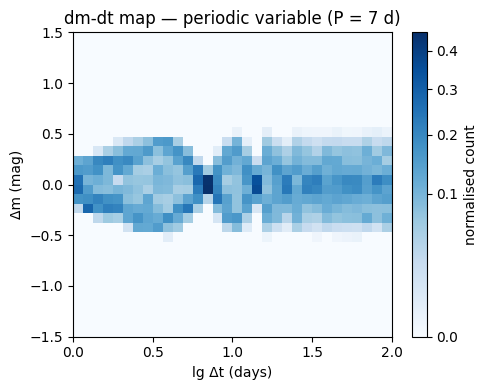

In [2]:
rng = np.random.default_rng(0)
t = np.sort(rng.uniform(0, 100, 200)).astype(np.float64)

period = 7.0
m = 15.0 + 0.2 * np.sin(2 * np.pi * t / period) + rng.normal(0, 0.03, 200)

map_ = dmdt.points(t, m)
print(f"Map shape: {map_.shape}  (lgdt_size × dm_size)")

plt.figure(figsize=(5, 4))
plt.imshow(
    map_.T,
    origin="lower",
    aspect="auto",
    extent=[0, 2, -1.5, 1.5],
    cmap="Blues",
    norm=mcolors.PowerNorm(gamma=0.5, vmin=0),
)
plt.xlabel("lg Δt (days)")
plt.ylabel("Δm (mag)")
plt.title("dm-dt map — periodic variable (P = 7 d)")
plt.colorbar(label="normalised count")
plt.tight_layout()


## Comparing light curve types

Different variability classes leave distinct signatures in dm-dt space:

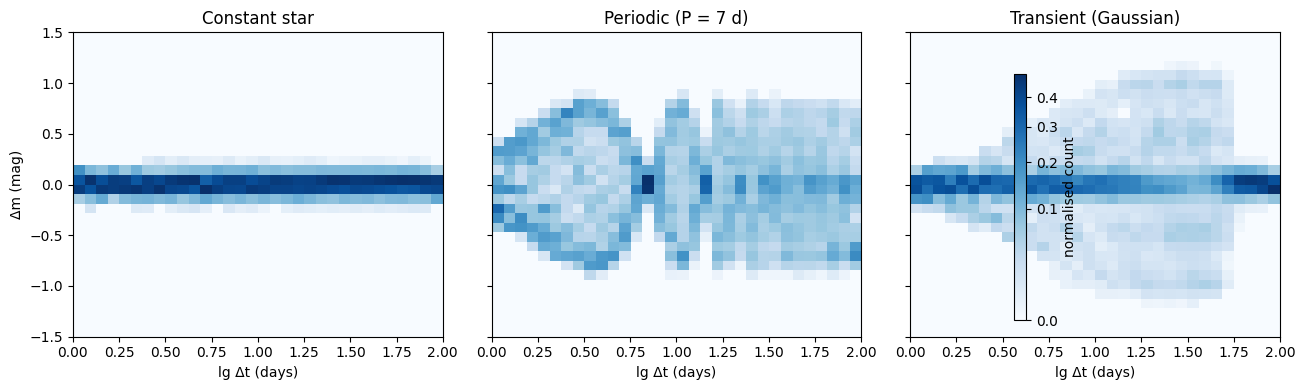

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

rng2 = np.random.default_rng(42)
t2 = np.sort(rng2.uniform(0, 100, 200)).astype(np.float64)

configs = [
    ("Constant star",       15.0 + rng2.normal(0, 0.05, 200)),
    ("Periodic (P = 7 d)", 15.0 + 0.4 * np.sin(2 * np.pi * t2 / 7) + rng2.normal(0, 0.03, 200)),
    ("Transient (Gaussian)", 15.0 - 1.0 * np.exp(-((t2 - 50) ** 2) / 50) + rng2.normal(0, 0.05, 200)),
]

for ax, (title, m2) in zip(axes, configs):
    mp = dmdt.points(t2, m2)
    img = ax.imshow(
        mp.T, origin="lower", aspect="auto",
        extent=[0, 2, -1.5, 1.5], cmap="Blues",
        norm=mcolors.PowerNorm(gamma=0.5, vmin=0),
    )
    ax.set_title(title)
    ax.set_xlabel("lg Δt (days)")

axes[0].set_ylabel("Δm (mag)")
fig.colorbar(img, ax=axes, label="normalised count", shrink=0.8)
fig.tight_layout()


## Error-weighted maps (`gausses`)

When photometric errors are known, use `.gausses()` to spread each observation pair
into a Gaussian kernel in Δm space. The third argument is the **variance** σ² (not σ):

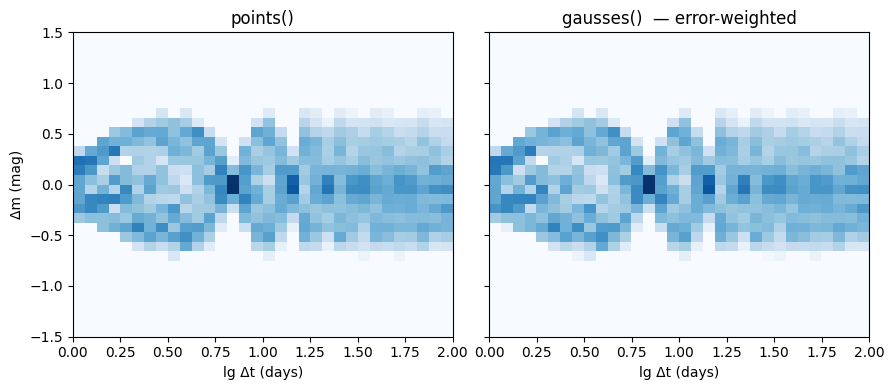

In [4]:
rng3 = np.random.default_rng(7)
t3 = np.sort(rng3.uniform(0, 100, 150)).astype(np.float64)
m3 = 15.0 + 0.3 * np.sin(2 * np.pi * t3 / 7) + rng3.normal(0, 0.04, 150)
err = np.full(150, 0.05)

map_pts  = dmdt.points(t3, m3)
map_gaus = dmdt.gausses(t3, m3, err ** 2)   # err² = variance

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
kw = dict(origin="lower", aspect="auto", extent=[0, 2, -1.5, 1.5],
          cmap="Blues", norm=mcolors.PowerNorm(gamma=0.5, vmin=0))
ax1.imshow(map_pts.T,  **kw)
ax1.set_title("points()")
ax2.imshow(map_gaus.T, **kw)
ax2.set_title("gausses()  — error-weighted")
for ax in (ax1, ax2):
    ax.set_xlabel("lg Δt (days)")
ax1.set_ylabel("Δm (mag)")
fig.tight_layout()


## Batch processing

`.points_many()` computes maps for a list of light curves in one call,
returning a 3D array of shape `(N, lgdt_size, dm_size)`:

In [5]:
rng4 = np.random.default_rng(99)
light_curves = []
for _ in range(100):
    n_obs = rng4.integers(50, 200)
    t_i = np.sort(rng4.uniform(0, 100, n_obs)).astype(np.float64)
    m_i = rng4.normal(15, 0.3, n_obs)
    light_curves.append((t_i, m_i))

maps = dmdt.points_many(light_curves)
print(f"Batch output shape: {maps.shape}  # (N, lgdt_size, dm_size)")
print(f"Ready for CNNs or flatten to (N, {maps.shape[1] * maps.shape[2]}) for sklearn.")


Batch output shape: (100, 32, 32)  # (N, lgdt_size, dm_size)
Ready for CNNs or flatten to (N, 1024) for sklearn.


## Notes

- `norm=["dt"]` makes each Δt row sum to ≤ 1, making maps comparable across cadences.
- `norm=["max"]` scales the entire map so its maximum cell equals 1.
- `.gausses()` requires **variances** σ² — square your error array before passing it.
- [API reference](api.md)